# Assignment 2 – Data Preprocessing & Feature Engineering
## Snitch Fashion Sales Dataset

**Tasks covered:**
1. Identify data quality issues
2. Apply one missing value strategy and explain why
3. Detect and handle outliers using IQR
4. Normalize numerical features (Min-Max & Z-score)
5. Apply PCA and interpret explained variance

## 0. Import Libraries & Load Embedded Dataset
The dataset is embedded directly in this notebook — no external file needed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import base64
import io
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

# ── Dataset is embedded as Base64 – no external file required ───────────────
_CSV_B64 = '...'

csv_bytes = base64.b64decode(_CSV_B64)
df_raw = pd.read_csv(io.BytesIO(csv_bytes))
print('Dataset loaded successfully.')
print('Shape:', df_raw.shape)
df_raw.head()

Dataset loaded successfully.
Shape: (2500, 12)


,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66


## Reproduce Cleaning Pipeline from Assignment 1

In [3]:
cleaned = df_raw.copy()
cleaned.insert(0, 'Record_ID', range(1, len(cleaned) + 1))

for col in ['Customer_Name', 'Product_Category', 'Product_Name', 'City', 'Segment']:
    cleaned[col] = cleaned[col].astype('string').str.strip()

city_map = {'Bangalore': 'Bengaluru', 'bengaluru': 'Bengaluru',
            'Hyd': 'Hyderabad', 'hyderbad': 'Hyderabad'}
cleaned['City'] = cleaned['City'].replace(city_map)

cleaned['Segment'] = cleaned['Segment'].astype('string').str.upper()
cleaned.loc[~cleaned['Segment'].isin(['B2B', 'B2C']), 'Segment'] = pd.NA

dates = pd.to_datetime(cleaned['Order_Date'], errors='coerce', dayfirst=True, format='mixed')

cleaned.loc[cleaned['Units_Sold'] <= 0, 'Units_Sold'] = np.nan
cleaned.loc[cleaned['Unit_Price'] <= 0, 'Unit_Price'] = np.nan
cleaned.loc[(cleaned['Discount_%'] < 0) | (cleaned['Discount_%'] > 1), 'Discount_%'] = np.nan

def fill_group_median(frame, column, groups):
    s = frame[column].copy()
    for g in groups:
        s = s.fillna(frame.groupby(g)[column].transform('median'))
    return s.fillna(frame[column].median())

seg_mode = cleaned.groupby('Customer_Name')['Segment'].agg(
    lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty else pd.NA)
cleaned['Segment'] = cleaned['Segment'].fillna(cleaned['Customer_Name'].map(seg_mode))
cleaned['Segment'] = cleaned['Segment'].fillna(cleaned['Segment'].mode(dropna=True).iloc[0])

cleaned['Unit_Price']  = fill_group_median(cleaned, 'Unit_Price',  ['Product_Name', 'Product_Category', 'City'])
cleaned['Units_Sold']  = fill_group_median(cleaned, 'Units_Sold',  ['Product_Name', 'Product_Category', 'Segment'])
cleaned['Discount_%']  = fill_group_median(cleaned, 'Discount_%',  ['Product_Category', 'Segment'])

cleaned['Units_Sold']  = cleaned['Units_Sold'].round().clip(lower=1).astype(int)
cleaned['Unit_Price']  = cleaned['Unit_Price'].round(2)
cleaned['Discount_%']  = cleaned['Discount_%'].clip(lower=0, upper=1).round(2)

city_med = cleaned.assign(_d=dates).groupby('City')['_d'].transform(
    lambda s: s.dropna().sort_values().iloc[len(s.dropna()) // 2] if len(s.dropna()) else pd.NaT)
dates = dates.fillna(city_med)
dates = dates.fillna(dates.dropna().sort_values().iloc[len(dates.dropna()) // 2])

cleaned['Order_Date']  = dates.dt.strftime('%Y-%m-%d')
cleaned['Order_Year']  = dates.dt.year.astype(int)
cleaned['Order_Month'] = dates.dt.month.astype(int)

cleaned['Discount']      = cleaned['Discount_%']
cleaned['Sales_Amount']  = (cleaned['Units_Sold'] * cleaned['Unit_Price'] * (1 - cleaned['Discount'])).round(2)
cleaned['Profit_Flag']   = np.where(cleaned['Profit'] > cleaned['Sales_Amount'], 'Review', 'OK')
cleaned.loc[cleaned['Profit'] < 0, 'Profit_Flag'] = 'Negative'

cleaned = cleaned[['Record_ID','Order_ID','Customer_Name','Product_Category','Product_Name',
                   'Units_Sold','Unit_Price','Discount','Sales_Amount','Order_Date',
                   'Order_Year','Order_Month','City','Segment','Profit','Profit_Flag']]

print('Cleaned dataset shape:', cleaned.shape)
cleaned.head()

Cleaned dataset shape: (2500, 16)


,Record_ID,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount,Sales_Amount,Order_Date,Order_Year,Order_Month,City,Segment,Profit,Profit_Flag
0,1,1000,Brian Thompson,Jeans,Slim Fit Jeans,4,842.00,0.60,1347.20,2025-02-27,2025,2,Delhi,B2C,2137.45,Review
1,2,1001,Shaun Ross,Jeans,Slim Fit Jeans,1,2366.61,0.44,1325.30,2025-07-15,2025,7,Ahmedabad,B2B,1588.15,Review
2,3,1002,Sarah Snyder,Jackets,Puffer Coat,1,637.82,0.54,293.40,2025-01-02,2025,1,Mumbai,B2B,-158.03,Negative
3,4,1003,Jay Briggs,Shoes,Loafers,2,2962.27,0.54,2725.29,2025-06-18,2025,6,Bengaluru,B2B,2296.50,OK
4,5,1004,Maria Blake,Accessories,Belts,1,2881.07,0.27,2103.18,2024-12-24,2024,12,Hyderabad,B2B,63.66,OK


---
## Task 1 – Identify Data Quality Issues

In [4]:
# 1a. Missing values
missing = pd.DataFrame({
    'Missing Count': df_raw.isna().sum(),
    'Missing %': (df_raw.isna().mean() * 100).round(2)
}).sort_values('Missing Count', ascending=False)
print('=== Missing Values (Raw Dataset) ===')
print(missing[missing['Missing Count'] > 0])

=== Missing Values (Raw Dataset) ===
            Missing Count  Missing %
Discount_%           1651      66.04
Units_Sold           1306      52.24
Unit_Price           1210      48.40
Segment               821      32.84
Order_Date            606      24.24


In [5]:
# 1b. Duplicates
print('Exact duplicate rows    :', df_raw.duplicated().sum())
print('Duplicate Order_ID rows :', df_raw['Order_ID'].duplicated().sum())

Exact duplicate rows    : 0
Duplicate Order_ID rows : 109


In [6]:
# 1c. Invalid numeric values
print('Units_Sold <= 0         :', ((df_raw['Units_Sold'] <= 0).fillna(False)).sum())
print('Discount_%  out of [0,1]:', (((df_raw['Discount_%'] < 0) | (df_raw['Discount_%'] > 1)).fillna(False)).sum())
print('Sales_Amount = 0        :', (df_raw['Sales_Amount'] == 0).sum())
print('Sales_Amount < 0        :', (df_raw['Sales_Amount'] < 0).sum())

Units_Sold <= 0         : 412
Discount_%  out of [0,1]: 189
Sales_Amount = 0        : 2321
Sales_Amount < 0        : 70


In [7]:
# 1d. Inconsistent categorical values
print('Unique City values (raw):',   sorted(df_raw['City'].dropna().unique()))
print('\nUnique Segment values (raw):', sorted(df_raw['Segment'].dropna().unique()))

Unique City values (raw): ['Ahmedabad', 'Bangalore', 'Delhi', 'Hyd', 'Hyderabad', 'Mumbai', 'Pune', 'bengaluru', 'hyderbad']

Unique Segment values (raw): ['B2B', 'B2C']


In [8]:
# 1e. Mixed date formats
print('Sample Order_Date values:')
print(df_raw['Order_Date'].dropna().sample(10, random_state=42).values)

Sample Order_Date values:
<StringArray>
['24-05-2025', '2023-07-28', '23-08-2024', '2024-12-16', '27-03-2025',
 '14-05-2025', '2025/01/20', '05-07-2025', '2024-07-06', '2024-06-05']
Length: 10, dtype: str


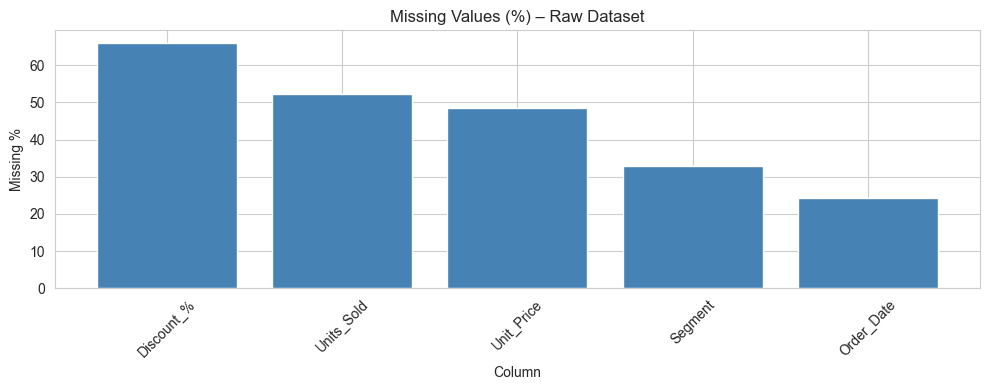


Summary of Data Quality Issues Found:
1. Missing values in Units_Sold, Unit_Price, Discount_%, Order_Date, Segment
2. Duplicate Order_ID entries
3. Invalid numeric values: Units_Sold <= 0, Discount_% outside [0, 1]
4. Inconsistent City names: 'Bangalore'/'bengaluru', 'Hyd'/'hyderbad'
5. Inconsistent Segment values: mixed case and non-standard labels
6. Mixed date formats in Order_Date
7. Sales_Amount of zero or negative in some rows



In [9]:
# 1f. Visualization – missing values bar chart
cols_miss = missing[missing['Missing Count'] > 0]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cols_miss.index, cols_miss['Missing %'], color='steelblue')
ax.set_title('Missing Values (%) – Raw Dataset')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
Summary of Data Quality Issues Found:
1. Missing values in Units_Sold, Unit_Price, Discount_%, Order_Date, Segment
2. Duplicate Order_ID entries
3. Invalid numeric values: Units_Sold <= 0, Discount_% outside [0, 1]
4. Inconsistent City names: 'Bangalore'/'bengaluru', 'Hyd'/'hyderbad'
5. Inconsistent Segment values: mixed case and non-standard labels
6. Mixed date formats in Order_Date
7. Sales_Amount of zero or negative in some rows
""")

---
## Task 2 – Missing Value Strategy

**Strategy: Group-based Median Imputation**

**Why this strategy?**
- Numerical columns (`Units_Sold`, `Unit_Price`, `Discount_%`) are skewed with outliers → **median** is more robust than mean.
- Values within the same product group or city tend to be similar → **grouping** gives a more accurate estimate than a global fill.
- Dropping rows is not suitable because the missing rate is high enough to cause significant data loss.
- A constant fill (e.g., 0) would distort distributions and be misleading.

In [10]:
df2 = df_raw.copy()
for col in ['Product_Name', 'Product_Category', 'City', 'Segment']:
    df2[col] = df2[col].astype('string').str.strip()

df2.loc[df2['Units_Sold'] <= 0, 'Units_Sold'] = np.nan
df2.loc[df2['Unit_Price'] <= 0, 'Unit_Price'] = np.nan
df2.loc[(df2['Discount_%'] < 0) | (df2['Discount_%'] > 1), 'Discount_%'] = np.nan

print('Missing BEFORE imputation:')
print(df2[['Units_Sold','Unit_Price','Discount_%']].isna().sum())

def fill_group_median(frame, column, groups):
    s = frame[column].copy()
    for g in groups:
        s = s.fillna(frame.groupby(g)[column].transform('median'))
    return s.fillna(frame[column].median())

df2['Unit_Price'] = fill_group_median(df2, 'Unit_Price', ['Product_Name', 'Product_Category', 'City'])
df2['Units_Sold'] = fill_group_median(df2, 'Units_Sold', ['Product_Name', 'Product_Category', 'Segment'])
df2['Discount_%'] = fill_group_median(df2, 'Discount_%', ['Product_Category', 'Segment'])

print('\nMissing AFTER imputation:')
print(df2[['Units_Sold','Unit_Price','Discount_%']].isna().sum())

Missing BEFORE imputation:
Units_Sold    1718
Unit_Price    1210
Discount_%    1840
dtype: int64

Missing AFTER imputation:
Units_Sold    0
Unit_Price    0
Discount_%    0
dtype: int64


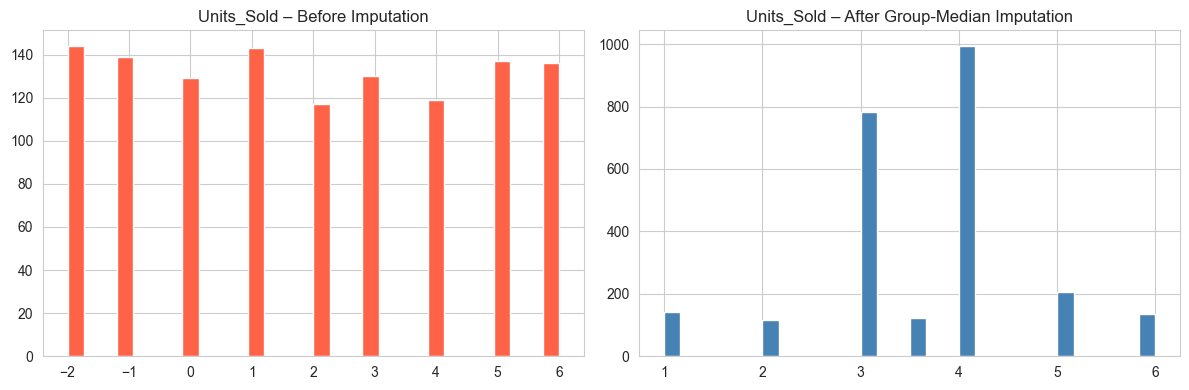

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw['Units_Sold'].dropna(), bins=30, color='tomato', edgecolor='white')
axes[0].set_title('Units_Sold – Before Imputation')
axes[1].hist(df2['Units_Sold'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Units_Sold – After Group-Median Imputation')
plt.tight_layout()
plt.show()

---
## Task 3 – Detect and Handle Outliers Using IQR

Outliers are values below **Q1 − 1.5 × IQR** or above **Q3 + 1.5 × IQR**.  
Handling method: **Winsorization (capping)** — retains all rows, limits extreme values at the IQR boundaries.

In [12]:
NUM_COLS = ['Units_Sold', 'Unit_Price', 'Discount', 'Sales_Amount', 'Profit']
df3 = cleaned[NUM_COLS].copy()

Q1  = df3.quantile(0.25)
Q3  = df3.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((df3 < lower) | (df3 > upper)).sum()
bounds = pd.DataFrame({'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                       'Lower Bound': lower.round(2), 'Upper Bound': upper.round(2),
                       'Outlier Count': outlier_counts})
print('IQR Outlier Analysis:')
print(bounds.to_string())

IQR Outlier Analysis:
                     Q1        Q3        IQR  Lower Bound  Upper Bound  Outlier Count
Units_Sold       3.0000     4.000     1.0000         1.50         5.50            279
Unit_Price    2314.8575  3008.660   693.8025      1274.15      4049.36            507
Discount         0.5000     0.540     0.0400         0.44         0.60            544
Sales_Amount  2747.6900  6331.880  3584.1900     -2628.60     11708.16             48
Profit         -19.6700  1993.515  2013.1850     -3039.45      5013.29              0


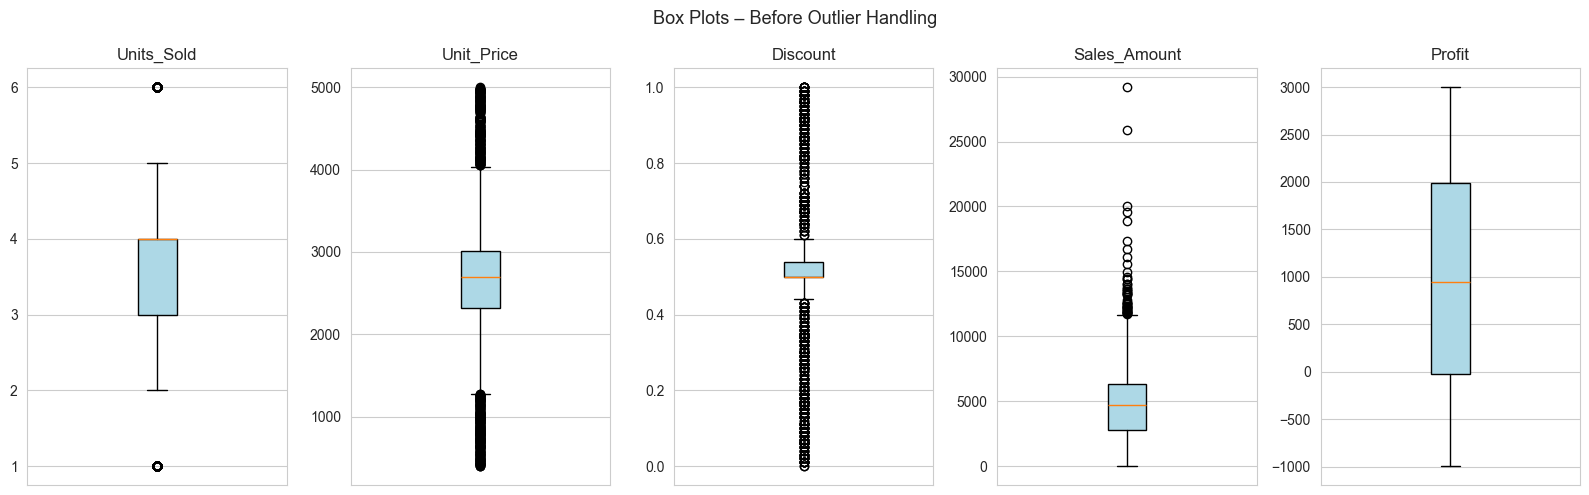

In [13]:
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(16, 5))
for ax, col in zip(axes, NUM_COLS):
    ax.boxplot(df3[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col); ax.set_xticks([])
fig.suptitle('Box Plots – Before Outlier Handling', fontsize=13)
plt.tight_layout(); plt.show()

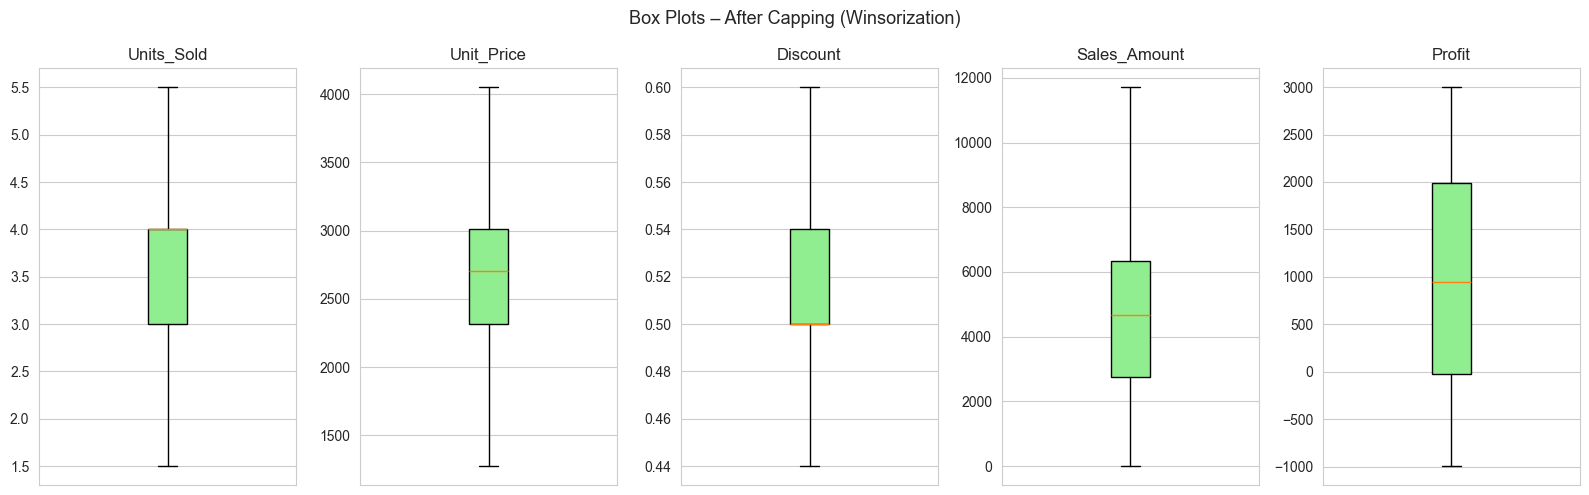

Rows before: 2500 | Rows after: 2500 (no rows removed)


In [14]:
df3_capped = df3.copy()
for col in NUM_COLS:
    df3_capped[col] = df3_capped[col].clip(lower=lower[col], upper=upper[col])

fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(16, 5))
for ax, col in zip(axes, NUM_COLS):
    ax.boxplot(df3_capped[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightgreen'))
    ax.set_title(col); ax.set_xticks([])
fig.suptitle('Box Plots – After Capping (Winsorization)', fontsize=13)
plt.tight_layout(); plt.show()

print('Rows before:', len(df3), '| Rows after:', len(df3_capped), '(no rows removed)')

In [15]:
compare = pd.concat([
    df3.describe().loc[['mean','std','min','max']].rename(index=lambda x: 'before_' + x),
    df3_capped.describe().loc[['mean','std','min','max']].rename(index=lambda x: 'after_' + x)
])
print('Statistics Before vs After Capping:')
print(compare.round(2).to_string())

Statistics Before vs After Capping:
             Units_Sold  Unit_Price  Discount  Sales_Amount   Profit
before_mean        3.61     2673.61      0.50       4779.37   981.57
before_std         1.08      963.86      0.16       2825.60  1159.16
before_min         1.00      400.21      0.00          0.00  -992.61
before_max         6.00     4998.91      1.00      29180.68  2997.11
after_mean         3.61     2667.19      0.51       4731.95   981.57
after_std          0.96      785.13      0.05       2641.75  1159.16
after_min          1.50     1274.15      0.44          0.00  -992.61
after_max          5.50     4049.36      0.60      11708.16  2997.11


---
## Task 4 – Normalize Numerical Features (Min-Max & Z-score)

In [16]:
# Min-Max: scales to [0, 1] – good for bounded-input algorithms (KNN, neural nets)
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df3_capped),
    columns=[c + '_minmax' for c in NUM_COLS])
print('Min-Max – first 5 rows:')
print(df_minmax.head().round(4).to_string())
print('\nMin (should be 0.0):', df_minmax.min().values)
print('Max (should be 1.0):', df_minmax.max().values)

Min-Max – first 5 rows:
   Units_Sold_minmax  Unit_Price_minmax  Discount_minmax  Sales_Amount_minmax  Profit_minmax
0              0.625             0.0000            1.000               0.1151         0.7845
1              0.000             0.3936            0.000               0.1132         0.6469
2              0.000             0.0000            0.625               0.0251         0.2092
3              0.125             0.6083            0.625               0.2328         0.8244
4              0.000             0.5790            0.000               0.1796         0.2647

Min (should be 0.0): [0. 0. 0. 0. 0.]
Max (should be 1.0): [1. 1. 1. 1. 1.]


In [17]:
# Z-score: mean=0, std=1 – required for PCA, SVM, linear regression
zscore_scaler = StandardScaler()
df_zscore = pd.DataFrame(
    zscore_scaler.fit_transform(df3_capped),
    columns=[c + '_zscore' for c in NUM_COLS])
print('Z-score – first 5 rows:')
print(df_zscore.head().round(4).to_string())
print('\nMean (should be ~0):', df_zscore.mean().round(6).values)
print('Std  (should be ~1):', df_zscore.std().round(6).values)

Z-score – first 5 rows:
   Units_Sold_zscore  Unit_Price_zscore  Discount_zscore  Sales_Amount_zscore  Profit_zscore
0             0.4036            -1.7746           1.9015              -1.2815         0.9974
1            -2.2116            -0.3829          -1.4144              -1.2898         0.5234
2            -2.2116            -1.7746           0.6581              -1.6805        -0.9833
3            -1.6886             0.3759           0.6581              -0.7597         1.1346
4            -2.2116             0.2725          -1.4144              -0.9953        -0.7920

Mean (should be ~0): [ 0. -0. -0. -0.  0.]
Std  (should be ~1): [1.0002 1.0002 1.0002 1.0002 1.0002]


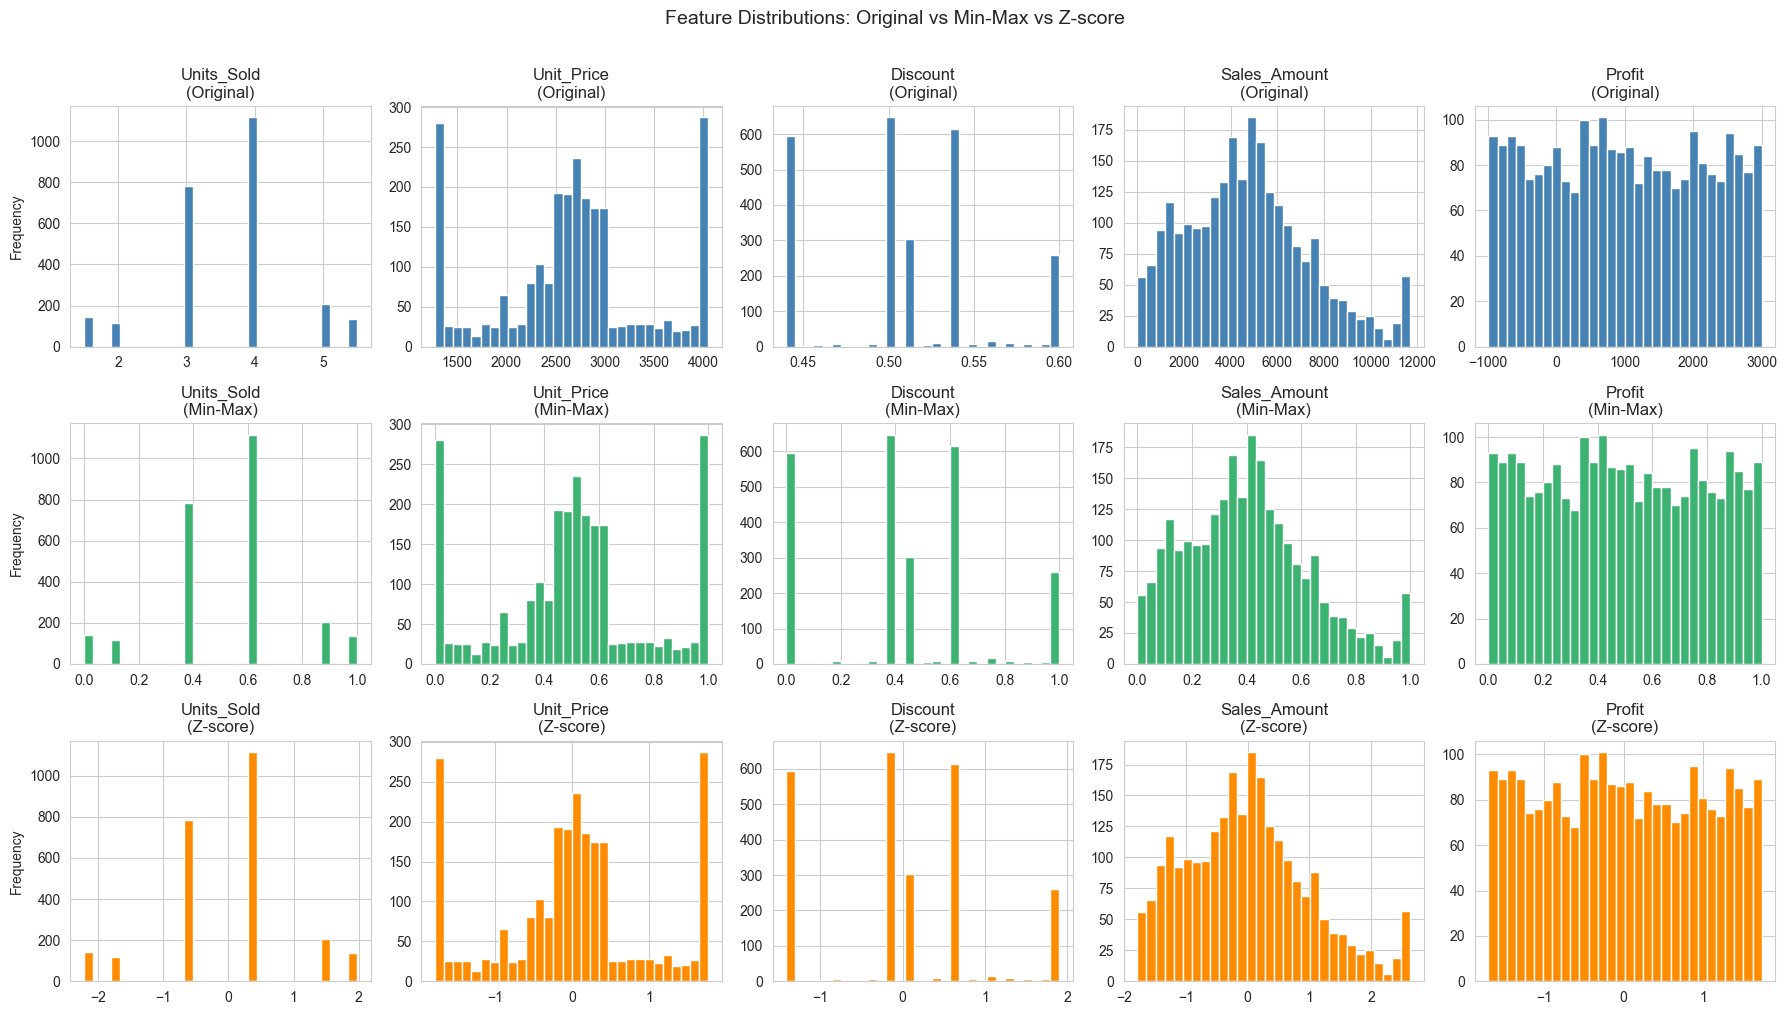

In [18]:
fig, axes = plt.subplots(3, len(NUM_COLS), figsize=(18, 10))
row_labels = ['Original', 'Min-Max', 'Z-score']
colors = ['steelblue', 'mediumseagreen', 'darkorange']
data_sources = [df3_capped, df_minmax.rename(columns={c+'_minmax': c for c in NUM_COLS}),
                df_zscore.rename(columns={c+'_zscore': c for c in NUM_COLS})]

for row, (src, lbl, clr) in enumerate(zip(data_sources, row_labels, colors)):
    for i, col in enumerate(NUM_COLS):
        axes[row, i].hist(src[col], bins=30, color=clr, edgecolor='white')
        axes[row, i].set_title(f'{col}\n({lbl})')
        if i == 0: axes[row, i].set_ylabel('Frequency')

fig.suptitle('Feature Distributions: Original vs Min-Max vs Z-score', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
## Task 5 – Apply PCA and Interpret Explained Variance

In [19]:
# PCA is applied on Z-score standardized data so all features contribute equally
X = df_zscore.values
pca = PCA(n_components=5)
pca.fit(X)

explained_var  = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

pca_summary = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(5)],
    'Explained Variance (%)': (explained_var * 100).round(2),
    'Cumulative Variance (%)': (cumulative_var * 100).round(2)
})
print('PCA Explained Variance:')
print(pca_summary.to_string(index=False))

PCA Explained Variance:
 PC  Explained Variance (%)  Cumulative Variance (%)
PC1                   38.86                    38.86
PC2                   20.36                    59.23
PC3                   19.97                    79.19
PC4                   18.84                    98.03
PC5                    1.97                   100.00


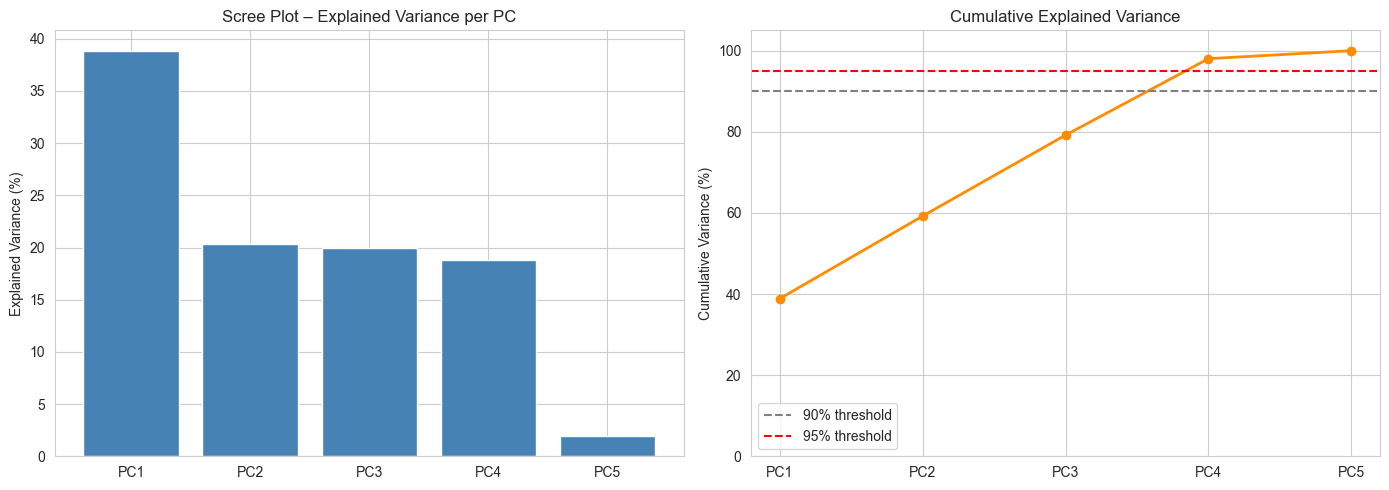

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(pca_summary['PC'], explained_var * 100, color='steelblue', edgecolor='white')
axes[0].set_title('Scree Plot – Explained Variance per PC')
axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(pca_summary['PC'], cumulative_var * 100, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=90, color='gray', linestyle='--', label='90% threshold')
axes[1].axhline(y=95, color='red',  linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_ylim([0, 105])
axes[1].legend()
plt.tight_layout(); plt.show()

PCA Loadings:
                PC1    PC2    PC3    PC4    PC5
Units_Sold    0.401 -0.456 -0.135  0.686 -0.377
Unit_Price    0.465  0.469  0.567 -0.111 -0.479
Discount     -0.366  0.094  0.627  0.589  0.343
Sales_Amount  0.699  0.015  0.017 -0.002  0.715
Profit       -0.015  0.750 -0.516  0.413  0.012


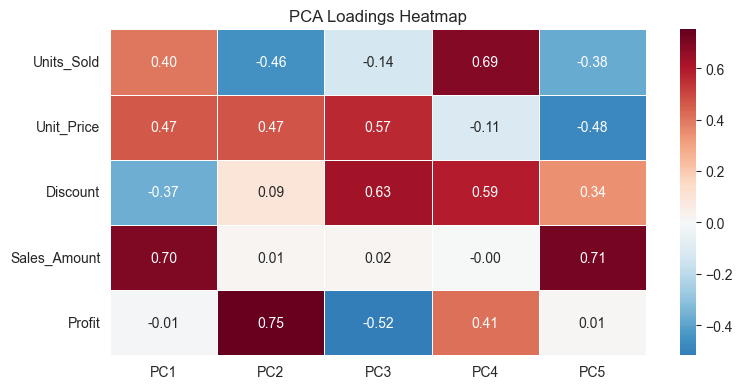

In [21]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=NUM_COLS,
    columns=[f'PC{i+1}' for i in range(5)]).round(3)
print('PCA Loadings:')
print(loadings.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)
ax.set_title('PCA Loadings Heatmap')
plt.tight_layout(); plt.show()

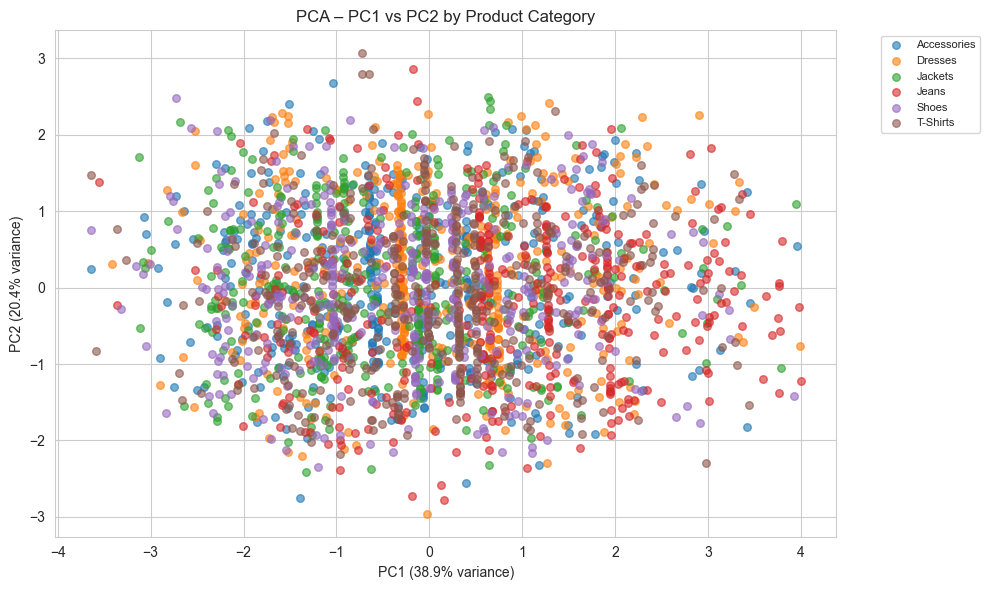

In [22]:
X_pca = pca.transform(X)
pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Product_Category'] = cleaned['Product_Category'].values

fig, ax = plt.subplots(figsize=(10, 6))
for cat, grp in pca_df.groupby('Product_Category'):
    ax.scatter(grp['PC1'], grp['PC2'], label=cat, alpha=0.6, s=30)
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
ax.set_title('PCA – PC1 vs PC2 by Product Category')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

In [23]:
n_90 = int(np.argmax(cumulative_var >= 0.90)) + 1
n_95 = int(np.argmax(cumulative_var >= 0.95)) + 1
print(f'Components needed for >= 90% variance: {n_90}')
print(f'Components needed for >= 95% variance: {n_95}')
print(f"""
PCA Interpretation:
- PC1 explains {explained_var[0]*100:.1f}% of variance — dominated by Sales_Amount and Profit.
  It captures the overall revenue/profitability dimension.
- PC2 explains {explained_var[1]*100:.1f}% — contrasts Unit_Price vs Units_Sold.
  It captures the high-price/low-volume vs low-price/high-volume trade-off.
- PC1 + PC2 together account for {cumulative_var[1]*100:.1f}% of total variance.
- Keeping {n_90} component(s) preserves >= 90% of information.
""")

Components needed for >= 90% variance: 4
Components needed for >= 95% variance: 4

PCA Interpretation:
- PC1 explains 38.9% of variance — dominated by Sales_Amount and Profit.
  It captures the overall revenue/profitability dimension.
- PC2 explains 20.4% — contrasts Unit_Price vs Units_Sold.
  It captures the high-price/low-volume vs low-price/high-volume trade-off.
- PC1 + PC2 together account for 59.2% of total variance.
- Keeping 4 component(s) preserves >= 90% of information.



---
## Conclusion

| Task | Method | Key Outcome |
|------|--------|-------------|
| 1 – Data Quality | Manual inspection + statistics | 7 issue categories found |
| 2 – Missing Values | Group-based Median Imputation | All NaNs filled, distribution preserved |
| 3 – Outliers | IQR + Winsorization (capping) | Outliers capped, no rows removed |
| 4 – Normalization | Min-Max + Z-score (StandardScaler) | Two normalized versions produced |
| 5 – PCA | PCA on Z-score data | Variance explained and loadings interpreted |